<a href="https://colab.research.google.com/github/ramcharan2823/AI/blob/NLP_ML/8_ANN_Practical_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
## import some basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [4]:
dataset = pd.read_csv("Churn_Modelling.csv")
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
## Divide the dataset into independent and dependent features.

X=dataset.iloc[:,3:13]
Y=dataset.iloc[:,13]

In [6]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [7]:
Y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [8]:
## Feature Engineering
geography = pd.get_dummies(X['Geography'],drop_first=True)
gender = pd.get_dummies(X['Gender'],drop_first=True)

In [9]:
## Concatenate these variables with dataframe

X = X.drop(['Geography','Gender'],axis=1)  ## to drop columns we need to add axis =1

In [10]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [11]:
pd.concat([X,geography,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [13]:
X=pd.concat([X,geography,gender],axis=1)

In [14]:
## splitting dataset into training set and test set
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [17]:
## feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [18]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [19]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [22]:
X_train.shape

(8000, 14)

In [23]:
## Part-2 Now lets create ANN

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout


In [25]:
## Lets initialize the ANN
classifier = Sequential()

In [26]:
## Adding the input layer
classifier.add(Dense(units=14,activation='relu'))

In [28]:
## Adding the first hidden layer
classifier.add(Dense(units=7,activation='relu'))

In [30]:
## Adding the second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [33]:
## Addig=ng the Output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [38]:
import tensorflow
opt=tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [39]:
classifier.compile(optimizer=opt,loss='binary_crossentropy',metrics=['accuracy'])

In [49]:
## early Stopping - when accuracy is not increaing then training will stop.
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    min_delta = 0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [50]:
model_history = classifier.fit(X_train,Y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8679 - loss: 0.3263 - val_accuracy: 0.8504 - val_loss: 0.3672
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8636 - loss: 0.3301 - val_accuracy: 0.8459 - val_loss: 0.3679
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8647 - loss: 0.3248 - val_accuracy: 0.8493 - val_loss: 0.3735
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8683 - loss: 0.3222 - val_accuracy: 0.8538 - val_loss: 0.3693
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8699 - loss: 0.3185 - val_accuracy: 0.8519 - val_loss: 0.3760
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8666 - loss: 0.3245 - val_accuracy: 0.8493 - val_loss: 0.3691
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8645 - loss: 0.3236 - val_accuracy: 0.8482 - val_loss: 0.3658
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8668 - loss: 0.3177 - 

In [51]:
model_history

In [52]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

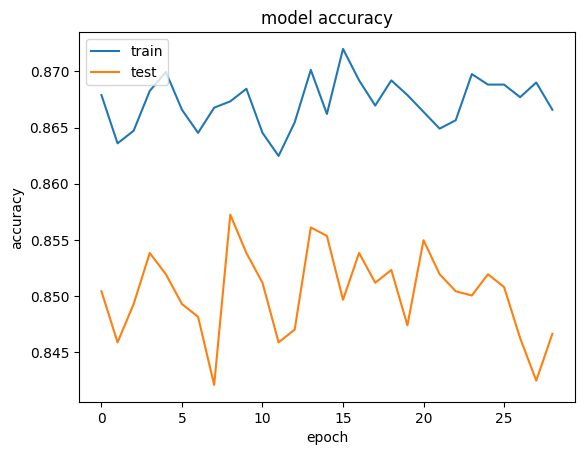

In [54]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

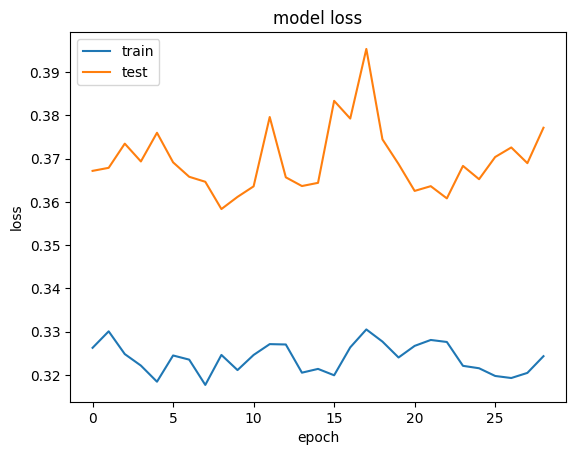

In [55]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [56]:
# part-3  making the predictions and evaluating the model

# predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [57]:
### make confusion matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,y_pred)
cm

array([[1545,   50],
       [ 217,  188]])

In [58]:
## calculate the accuracy
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred,Y_test)

In [59]:
score

0.8665

In [60]:
## get the weights
classifier.get_weights()

[array([[-7.0170617e-01,  2.4330574e-01, -2.7299364e+00,  2.8519031e-01,
          1.4395674e+00,  1.2766807e+00, -7.8073077e-02,  7.6612008e-01,
          2.3681055e-01,  2.2965710e+00,  7.1153826e-01, -9.8259293e-02,
          2.7582335e+00,  8.6552316e-01],
        [ 1.6967294e-01, -1.2482806e+00, -4.5234208e+00, -6.0273905e+00,
         -3.1261241e+00, -6.6620836e+00,  3.9790049e+00,  1.3769696e+00,
         -5.2247038e+00, -1.9005812e+00, -2.6905537e-01, -4.6127018e-02,
         -4.4078946e+00, -2.5579488e+00],
        [-2.8983920e+00, -4.2045876e-01, -1.1368479e+00,  1.3374332e+00,
         -3.0391080e+00, -1.6533741e+00, -5.7864571e-01,  1.2878717e+00,
         -1.0331656e+00,  9.1303855e-01,  6.1493050e-02,  1.5722314e-01,
         -5.3922046e-02, -2.9308069e-01],
        [ 4.2219052e+00, -6.6268215e+00,  3.1841221e+00,  1.1768321e+00,
          2.9837883e+00, -3.0804331e+00,  5.4410571e-01, -8.9386982e-01,
         -6.9888657e-01, -2.5167971e+00,  1.4819251e-02,  2.2132817e-01